In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


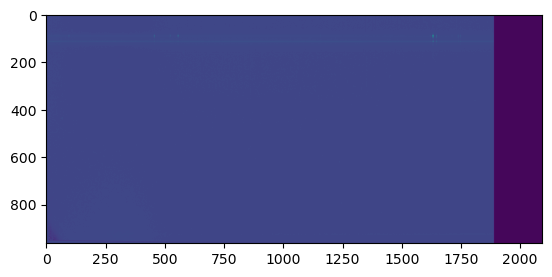

In [3]:
plt.imshow(image)

In [3]:
image_cut = image[55:155, 0:1800]

Text(0.5, 0, 'wavelenght')

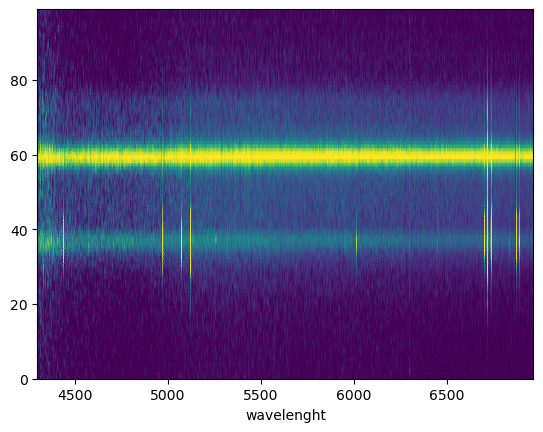

In [4]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

Text(0.5, 0, 'wavelenght')

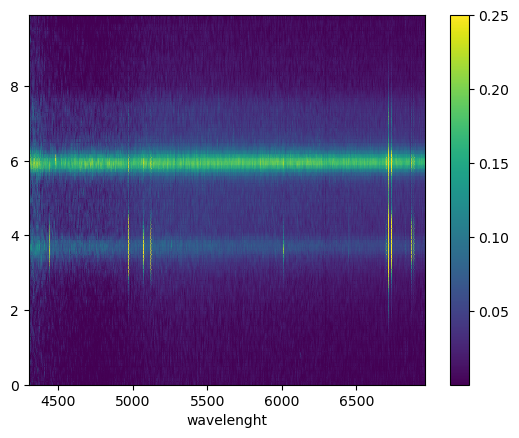

In [6]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
fig = plt.figure()
ax  = fig.add_subplot()
pmesh = ax.pcolormesh(x_grid, 0.1*y_grid, (image_cut), shading='gouraud',cmap='viridis',vmin=0.00000085,vmax=0.25)
cbar = plt.colorbar(pmesh,ax=ax)
plt.xlabel('wavelenght')

We know that redshift and wavelenghts are related in this way:
$\lambda_{obs} = \lambda_{em}*(1+z)$ \\
So if we want:
- $\lambda_{obs}(H\alpha)$ = 6563 * (1+0.0238) = 6719 AA
- $\lambda_{obs}(H\beta)$ = 4861 * (1+0.0238) = 4977 AA
- $\lambda_{obs}([NII])$ = 6548 * (1+0.0238) = 6704 AA
- $\lambda_{obs}([SII])$ = 6717 * (1+0.0238) = 6877 AA
- $\lambda_{obs}([OIII])$ = 4959 * (1+0.0238) = 5077 AA


## Continuum 6500 AA

Text(0.5, 1.0, 'Continuum 6500 A')

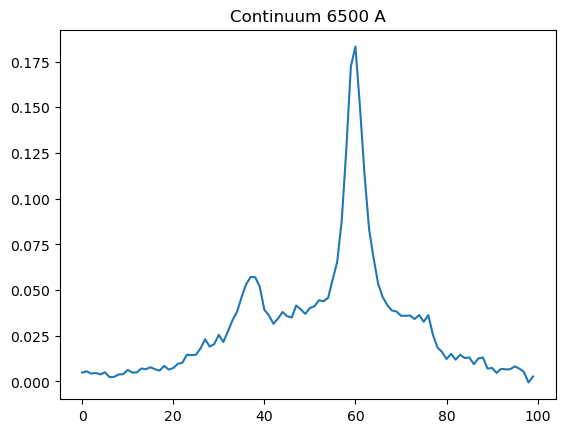

In [6]:
mask = (wavelenghts > 6490)*(wavelenghts < 6510)
image_6500 = image_cut[:, mask] #cut su 6500 A
radial_profile = np.mean(image_6500, axis = 1)
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile)
plt.title('Continuum 6500 A')

## H$\alpha$

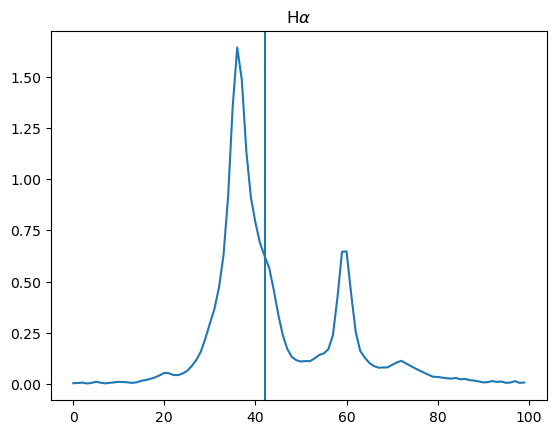

In [7]:
mask_HA = (wavelenghts > 6714)*(wavelenghts < 6724)
image_HA = image_cut[:, mask_HA]
#image_HA = image_cut[6719]#cut su 6719 A
radial_profile_HA = np.mean(image_HA, axis = 1)
plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')
plt.axvline(42)

The fit gives us these parameters: A = 1.09, A2 = 0.50, mu = 36.30, mu2 = 59.57


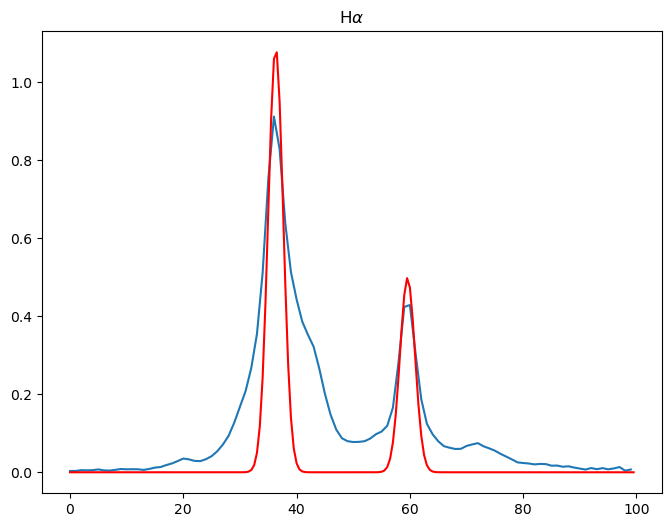

In [26]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2):
    gauss1 = A*np.exp(-(x-mu)**2/(2*sigma**2))
    gauss2 = A2*np.exp(-(x-mu2)**2/(2*sigma**2))
    return gauss1+gauss2
    
params, covariance = curve_fit(model, x_axes, radial_profile_HA, p0=[0.8, 0.4, 40, 60])
A, A2, mu, mu2 = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f' % (A, A2, mu, mu2))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5)

plt.show()

C:\Users\ISAFA\anaconda3\Lib\site-packages\astropy\modeling\functional_models.py:858: RuntimeWarning: invalid value encountered in power
  -cls._gammaincinv(2 * n, 0.5) * ((r / r_eff) ** (1 / n) - 1)
C:\Users\ISAFA\anaconda3\Lib\site-packages\astropy\modeling\functional_models.py:858: RuntimeWarning: divide by zero encountered in power
  -cls._gammaincinv(2 * n, 0.5) * ((r / r_eff) ** (1 / n) - 1)


The fit gives us these parameters: A = 1.71, A2 = 0.53, mu = 36.29, mu2 = 59.56, As = 0.16, r_eff = 51.50, n = 0.11


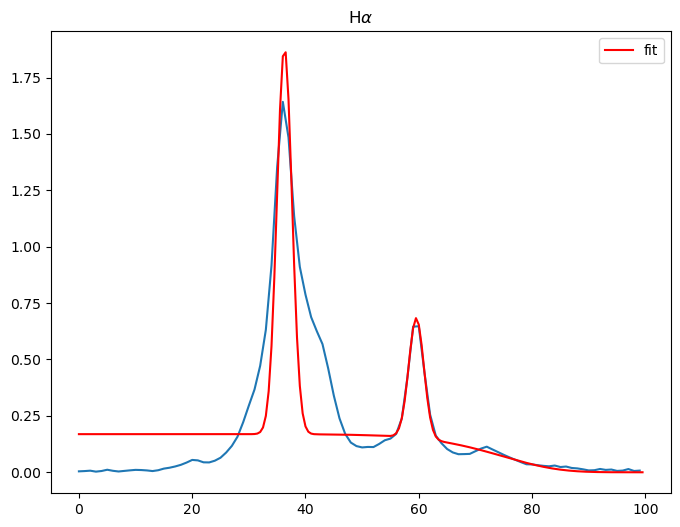

In [64]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_HA, p0=[0.8, 0.4, 40, 60, 1, 50, 1])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()

plt.show()

The fit gives us these parameters: Ie1 = 0.37, re1 = 5.02, n1 = 0.93, x01 = 36.25, Ie2 = 0.0020, r_eff_2 = 136.65, n2 = 4.00, x02 = 59.50, Ie3 = 0.1529, r_eff_3 = 2.80, n3 = 0.50, x03 = 42.58 


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_6060\1826044007.py:15: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r/r_e)**(1/n) - 1))


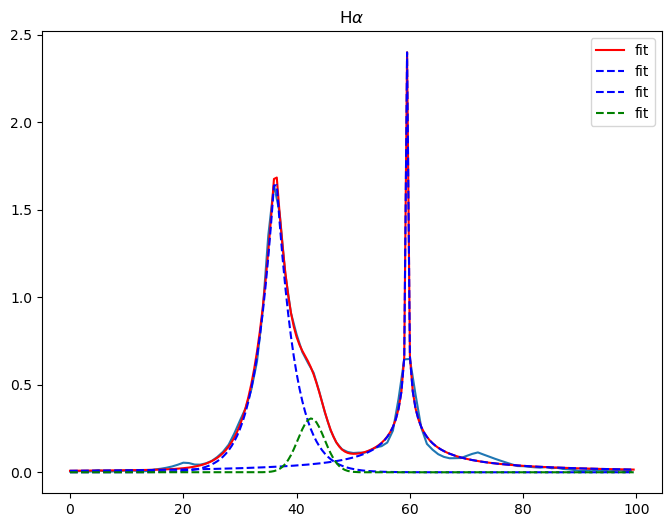

In [65]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def calculate_bn(n):
    """
    Calcola il parametro b_n per il profilo di Sérsic.
    Approssimazione valida per 0.5 < n < 10.
    """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)
    
def sersic_1d(x, I_e, r_e, n, x_0):
    # x_0 è il centro del profilo come parametro libero
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r/r_e)**(1/n) - 1))

def model(x, I_e1, r_e1, n1, x_01, I_e2, r_e2, n2, x_02, I_e3, r_e3, n3, x_03):
    return sersic_1d(x, I_e1, r_e1, n1, x_01)+sersic_1d(x, I_e2, r_e2, n2, x_02)+sersic_1d(x, I_e3, r_e3, n3, x_03)

bounds = ([0, 0, 0, 35, 0, 0, 0, 55, 0, 0, 0, 45], [1e-2, 10, 0.7, 45, 1e-3, 30, 0.7, 65, 1e-3, np.inf, 55] )
print(bounds)

params, covariance = curve_fit(model, x_axes, radial_profile_HA, p0=[1, 1, 0.5, 38, 1e-3, 1, 0.5, 58.5, 1e-3, 50, 0.5, 50], method ='trf', bounds = bounds)
I_e1, r_e1, n1, x_01, I_e2, r_e2, n2, x_02, I_e3, r_e3, n3, x_03 = params
print(r'The fit gives us these parameters: Ie1 = %.2f, re1 = %.2f, n1 = %.2f, x01 = %.2f, Ie2 = %.4f, r_eff_2 = %.2f, n2 = %.2f, x02 = %.2f, Ie3 = %.4f, r_eff_3 = %.2f, n3 = %.2f, x03 = %.2f ' % (I_e1, r_e1, n1, x_01, I_e2, r_e2, n2, x_02, I_e3, r_e3, n3, x_03))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.plot(xgrid, sersic_1d(xgrid, I_e1, r_e1, n1, x_01), color = 'blue', lw = 1.5, label ='fit', linestyle= '--')
plt.plot(xgrid, sersic_1d(xgrid, I_e2, r_e2, n2, x_02), color = 'blue', lw = 1.5, label ='fit', linestyle= '--')
plt.plot(xgrid, sersic_1d(xgrid, I_e3, r_e3, n3, x_03), color = 'green', lw = 1.5, label ='fit', linestyle= '--')
plt.legend()

plt.show()

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_6060\1540190078.py:15: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r/r_e)**(1/n) - 1))


The fit gives us these parameters: Ie1 = 0.38, re1 = 4.65, n1 = 0.89, Ie2 = 0.1609, r_eff_2 = 2.98, n2 = 0.93, Ie3 = 0.0265, r_eff_3 = 20.77, n3 = 1.69, Ie4 = 0.0184, r_eff_4 = 11.67, n4 = 1.02 


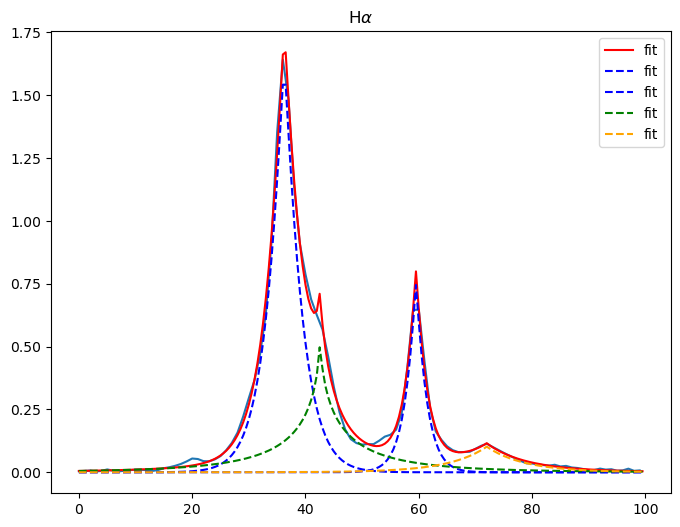

In [76]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def calculate_bn(n):
    """
    Calcola il parametro b_n per il profilo di Sérsic.
    Approssimazione valida per 0.5 < n < 10.
    """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)
    
def sersic_1d(x, I_e, r_e, n, x_0):
    # x_0 è il centro del profilo come parametro libero
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r/r_e)**(1/n) - 1))

def model(x, I_e1, r_e1, n1, I_e2, r_e2, n2, I_e3, r_e3, n3, I_e4, r_e4, n4):
    return sersic_1d(x, I_e1, r_e1, n1, 36.25)+sersic_1d(x, I_e2, r_e2, n2, 59.50)+sersic_1d(x, I_e3, r_e3, n3, 42.58)+sersic_1d(x, I_e4, r_e4, n4, 72)

#bounds = ([0, 0, 0, 35, 0, 0, 0, 55, 0, 0, 0, 45], [1, 10, 0.7, 45, 1e-3, 30, 0.7, 65, 1e-3, 100, 0.7, 55] )
#print(bounds)

params, covariance = curve_fit(model, x_axes, radial_profile_HA, p0=[1, 1, 0.5, 1e-3, 1, 0.5, 1e-3, 50, 0.5, 1e-3, 1, 0.5]) #method ='trf', bounds = bounds)
I_e1, r_e1, n1, I_e2, r_e2, n2, I_e3, r_e3, n3, I_e4, r_e4, n4 = params
print(r'The fit gives us these parameters: Ie1 = %.2f, re1 = %.2f, n1 = %.2f, Ie2 = %.4f, r_eff_2 = %.2f, n2 = %.2f, Ie3 = %.4f, r_eff_3 = %.2f, n3 = %.2f, Ie4 = %.4f, r_eff_4 = %.2f, n4 = %.2f ' % (I_e1, r_e1, n1, I_e2, r_e2, n2, I_e3, r_e3, n3, I_e4, r_e4, n4) )
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.plot(xgrid, sersic_1d(xgrid, I_e1, r_e1, n1, 36.25), color = 'blue', lw = 1.5, label ='fit', linestyle= '--')
plt.plot(xgrid, sersic_1d(xgrid, I_e2, r_e2, n2, 59.50), color = 'blue', lw = 1.5, label ='fit', linestyle= '--')
plt.plot(xgrid, sersic_1d(xgrid, I_e3, r_e3, n3, 42.58), color = 'green', lw = 1.5, label ='fit', linestyle= '--')
plt.plot(xgrid, sersic_1d(xgrid, I_e4, r_e4, n4, 72), color = 'orange', lw = 1.5, label ='fit', linestyle= '--')
plt.legend()

plt.show()

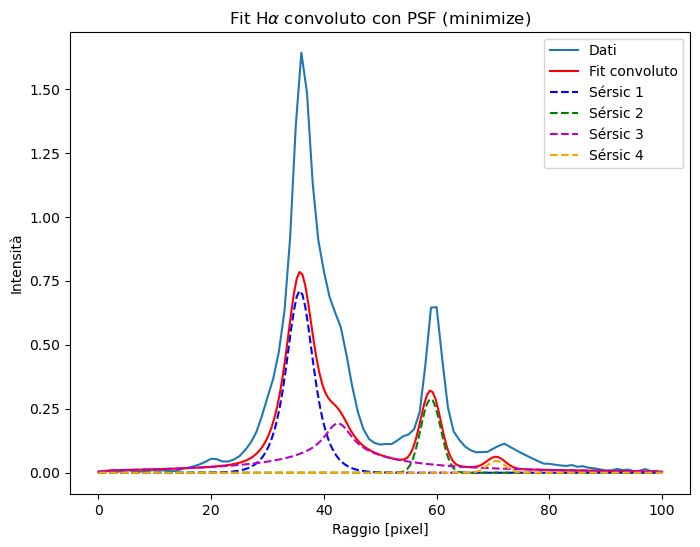

Parametri ottimizzati:
 [4.28382585e-01 3.57254562e+00 9.54497760e-01 3.52396504e+01
 5.61449818e-01 1.27229658e+00 3.05921986e-01 5.84459130e+01
 1.29912518e-02 4.99871380e+01 2.15553143e+00 4.20000000e+01
 9.28671323e-02 1.01097059e+00 3.99776335e-01 7.00568973e+01]


In [23]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo di Sérsic. """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo di Sérsic 1D centrato in x_0. """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r/r_e)**(1/n) - 1))

def gaussian_psf(x, fwhm):
    """ PSF gaussiana normalizzata. """
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    psf = np.exp(-x**2 / (2 * sigma**2))
    return psf / np.sum(psf)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, fwhm):
    """ Profilo di Sérsic convoluto con PSF gaussiana. """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    dx = x[1] - x[0]
    psf_x = x - x[len(x)//2]
    psf = gaussian_psf(psf_x, fwhm)
    conv_profile = convolve(profile, psf, mode='same') * dx
    return conv_profile

def model_convolved(x, I_e1, r_e1, n1, x_01, I_e2, r_e2, n2, x_02, I_e3, r_e3, n3, x_03, I_e4, r_e4, n4, x_04, fwhm):
    return (sersic_1d_convolved(x, I_e1, r_e1, n1, x_01, fwhm) +
        sersic_1d_convolved(x, I_e2, r_e2, n2, x_02, fwhm) +
        sersic_1d_convolved(x, I_e3, r_e3, n3, x_03, fwhm) +
        sersic_1d_convolved(x, I_e4, r_e4, n4, x_04, fwhm))

def chi_squared(params, x, y_obs, fwhm):
    I_e1, r_e1, n1, x_01, I_e2, r_e2, n2, x_02, I_e3, r_e3, n3, x_03, I_e4, r_e4, n4, x_04 = params
    y_model = model_convolved(x, I_e1, r_e1, n1, x_01, I_e2, r_e2, n2, x_02, I_e3, r_e3, n3, x_03, I_e4, r_e4, n4, x_04, fwhm)
    return np.sum((y_obs - y_model)**2)
    
initial_guess = [1, 1, 0.5, 36, 1e-3, 1, 0.5, 60,  1e-3, 50, 0.5, 42, 1e-3, 1, 0.5, 70]
fwhm_psf = 3.125  # oppure ciò che hai calcolato

result = minimize(
    chi_squared,
    x0=initial_guess,
    args=(x_axes, radial_profile_HA, fwhm_psf),
    method='L-BFGS-B',
    options={'maxiter': 10000, 'disp': True}
)    

xgrid = np.arange(0, 100, 0.5)
    
best_params = result.x
xgrid = np.linspace(0, 100, 200)
y_fit = model_convolved(xgrid, *best_params, fwhm_psf)

plt.figure(figsize=(8, 6))
plt.plot(x_axes, radial_profile_HA, label='Dati')
plt.plot(xgrid, y_fit, 'r-', label='Fit convoluto')

# Componenti singoli
plt.plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4], fwhm_psf), 'b--', label='Sérsic 1')
plt.plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8], fwhm_psf), 'g--', label='Sérsic 2')
plt.plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12], fwhm_psf), 'm--', label='Sérsic 3')
plt.plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16], fwhm_psf), 'orange', linestyle='--', label='Sérsic 4')

plt.xlabel("Raggio [pixel]")
plt.ylabel("Intensità")
plt.title(r"Fit H$\alpha$ convoluto con PSF (minimize)")
plt.legend()
plt.show()
print("Parametri ottimizzati:\n", best_params)

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

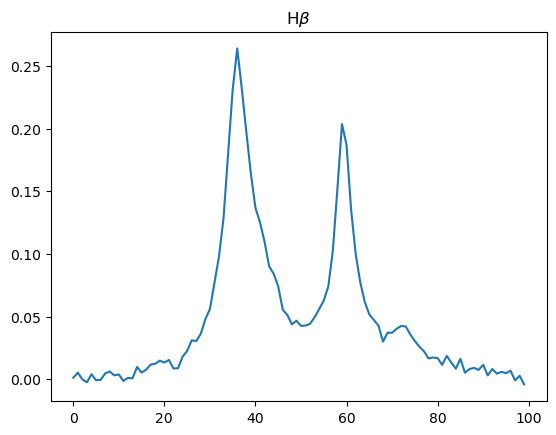

In [78]:
mask_HB = (wavelenghts > 4967)*(wavelenghts < 4987)
image_HB = image_cut[:, mask_HB] #cut su 4977 A
radial_profile_HB = np.mean(image_HB, axis = 1)
plt.plot(x_axes, radial_profile_HB)
plt.title(r'H$\beta$')

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_6060\3243681804.py:15: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r/r_e)**(1/n) - 1))


The fit gives us these parameters: Ie1 = 0.06, re1 = 4.78, n1 = 0.81, Ie2 = 0.0389, r_eff_2 = 4.33, n2 = 1.00, Ie3 = 0.0105, r_eff_3 = 21.57, n3 = 1.06, Ie4 = 0.0054, r_eff_4 = 16.98, n4 = 1.13 


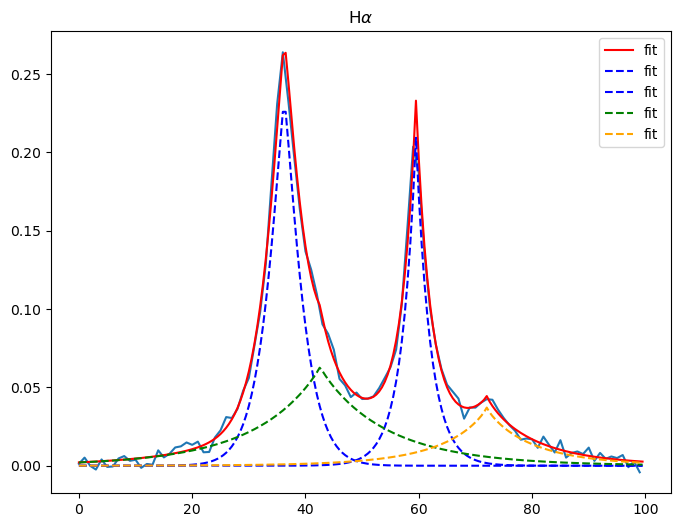

In [79]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def calculate_bn(n):
    """
    Calcola il parametro b_n per il profilo di Sérsic.
    Approssimazione valida per 0.5 < n < 10.
    """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)
    
def sersic_1d(x, I_e, r_e, n, x_0):
    # x_0 è il centro del profilo come parametro libero
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r/r_e)**(1/n) - 1))

def model(x, I_e1, r_e1, n1, I_e2, r_e2, n2, I_e3, r_e3, n3, I_e4, r_e4, n4):
    return sersic_1d(x, I_e1, r_e1, n1, 36.25)+sersic_1d(x, I_e2, r_e2, n2, 59.50)+sersic_1d(x, I_e3, r_e3, n3, 42.58)+sersic_1d(x, I_e4, r_e4, n4, 72)

#bounds = ([0, 0, 0, 35, 0, 0, 0, 55, 0, 0, 0, 45], [1, 10, 0.7, 45, 1e-3, 30, 0.7, 65, 1e-3, 100, 0.7, 55] )
#print(bounds)

params, covariance = curve_fit(model, x_axes, radial_profile_HB, p0=[1, 1, 0.5, 1e-3, 1, 0.5, 1e-3, 50, 0.5, 1e-3, 1, 0.5]) #method ='trf', bounds = bounds)
I_e1, r_e1, n1, I_e2, r_e2, n2, I_e3, r_e3, n3, I_e4, r_e4, n4 = params
print(r'The fit gives us these parameters: Ie1 = %.2f, re1 = %.2f, n1 = %.2f, Ie2 = %.4f, r_eff_2 = %.2f, n2 = %.2f, Ie3 = %.4f, r_eff_3 = %.2f, n3 = %.2f, Ie4 = %.4f, r_eff_4 = %.2f, n4 = %.2f ' % (I_e1, r_e1, n1, I_e2, r_e2, n2, I_e3, r_e3, n3, I_e4, r_e4, n4) )
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HB)
plt.title(r'H$\alpha$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.plot(xgrid, sersic_1d(xgrid, I_e1, r_e1, n1, 36.25), color = 'blue', lw = 1.5, label ='fit', linestyle= '--')
plt.plot(xgrid, sersic_1d(xgrid, I_e2, r_e2, n2, 59.50), color = 'blue', lw = 1.5, label ='fit', linestyle= '--')
plt.plot(xgrid, sersic_1d(xgrid, I_e3, r_e3, n3, 42.58), color = 'green', lw = 1.5, label ='fit', linestyle= '--')
plt.plot(xgrid, sersic_1d(xgrid, I_e4, r_e4, n4, 72), color = 'orange', lw = 1.5, label ='fit', linestyle= '--')
plt.legend()

plt.show()

The fit gives us these parameters: A = 0.26, A2 = 0.18, mu = 36.15, mu2 = 59.36, As = 0.04, r_eff = 56.28, n = 0.07


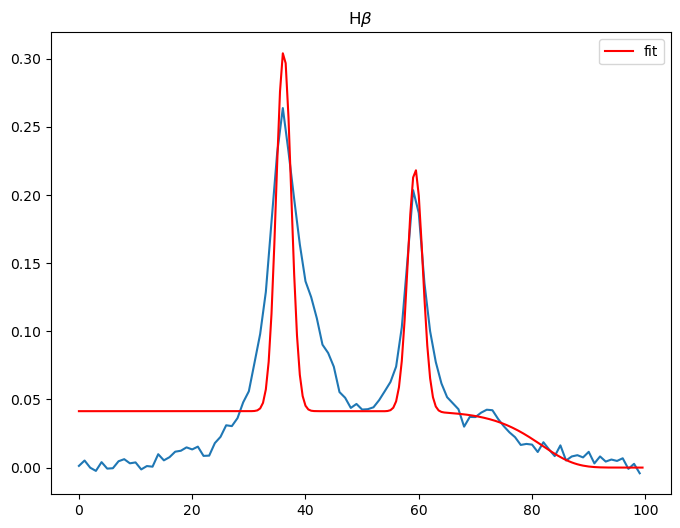

In [40]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_HB, p0=[0.25, 0.2, 40, 60, 0.1, 50, 0.1])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HB)
plt.title(r'H$\beta$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()

## [NII]

Text(0.5, 1.0, '[NII]')

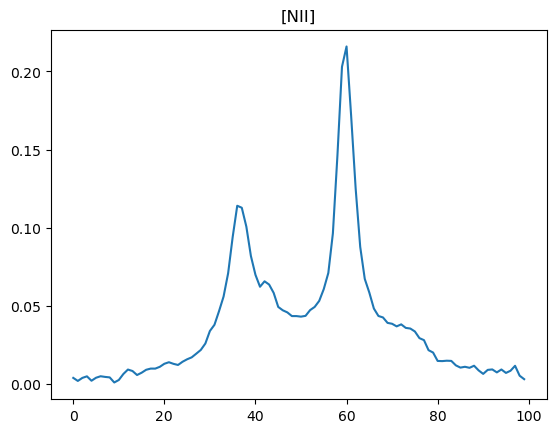

In [33]:
mask_NII = (wavelenghts > 6694)*(wavelenghts < 6714)
image_NII = image_cut[:, mask_NII] #cut su 6704 A
radial_profile_NII = np.mean(image_NII, axis = 1)
plt.plot(x_axes, radial_profile_NII)
plt.title(r'[NII]')

The fit gives us these parameters: A = 0.10, A2 = 0.21, mu = 36.69, mu2 = 59.75, As = 0.03, r_eff = 59.11, n = 0.06


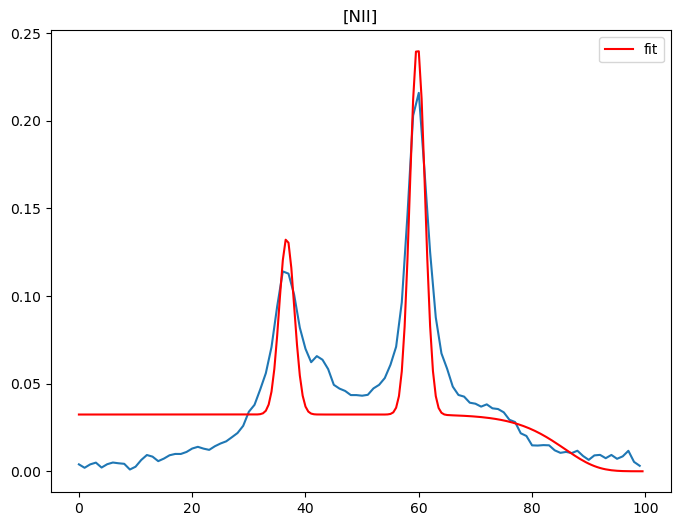

In [39]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_NII, p0=[0.15, 0.2, 40, 60, 0.05, 50, 0.05])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_NII)
plt.title(r'[NII]')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()

## [SII]

Text(0.5, 1.0, '[SII]')

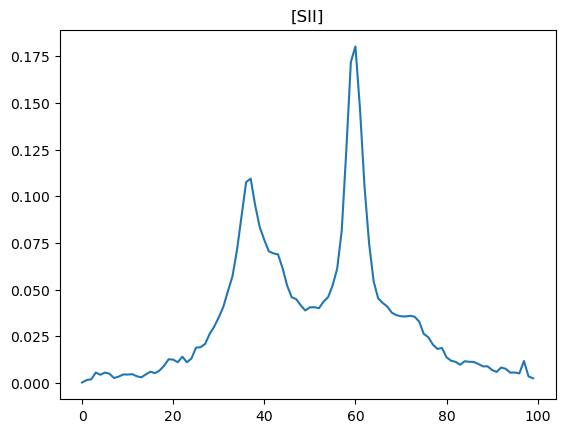

In [37]:
mask_SII = (wavelenghts > 6867)*(wavelenghts < 6887)
image_SII = image_cut[:, mask_SII] #cut su 6877 A
radial_profile_SII = np.mean(image_SII, axis = 1)
plt.plot(x_axes, radial_profile_SII)
plt.title(r'[SII]')

The fit gives us these parameters: A = 0.10, A2 = 0.17, mu = 36.76, mu2 = 59.75, As = 0.03, r_eff = 58.34, n = 0.06


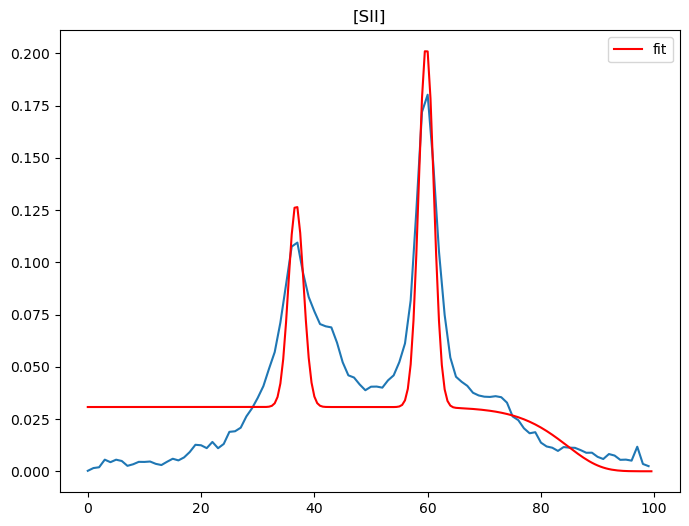

In [41]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_SII, p0=[0.125, 0.175, 40, 60, 0.05, 50, 0.05])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_SII)
plt.title(r'[SII]')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()

## [OIII]

Text(0.5, 1.0, '[OIII]')

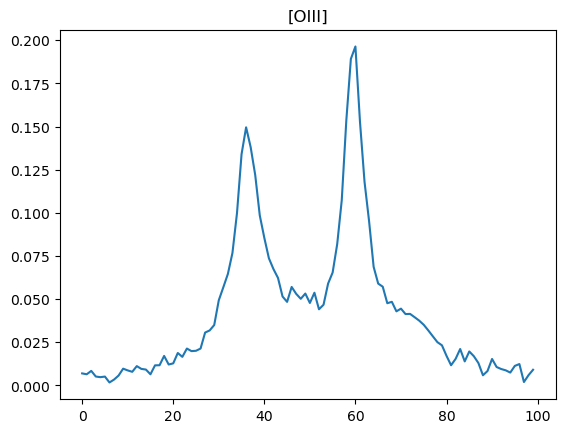

In [42]:
mask_OIII = (wavelenghts > 5067)*(wavelenghts < 5087)
image_OIII = image_cut[:, mask_OIII] #cut su 5077 A
radial_profile_OIII = np.mean(image_OIII, axis = 1)
plt.plot(x_axes, radial_profile_OIII)
plt.title(r'[OIII]')

The fit gives us these parameters: A = 0.13, A2 = 0.19, mu = 36.30, mu2 = 59.57, As = 0.04, r_eff = 59.43, n = 0.07


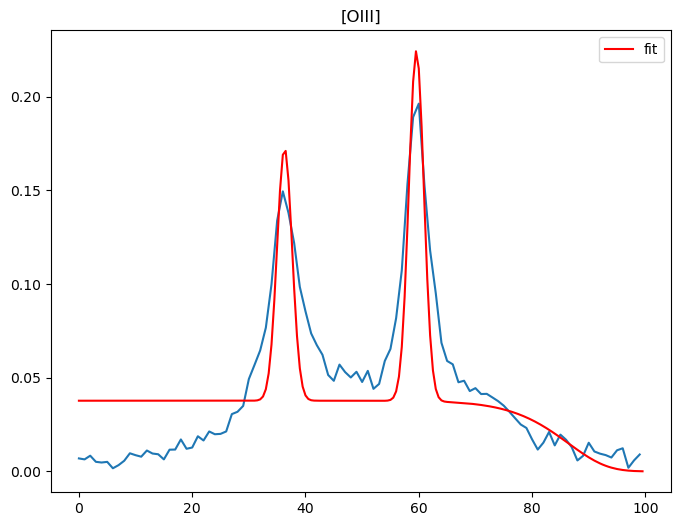

In [43]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_OIII, p0=[0.15, 0.2, 40, 60, 0.1, 50, 0.1])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_OIII)
plt.title(r'[OIII]')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()